# STEP 1 — LOAD DATA

In [1]:
import csv 
from dotenv import load_dotenv
import os
import pandas as pd
from sqlalchemy import create_engine

load_dotenv()

HOST=os.getenv("DB_HOST")
USER=os.getenv("DB_USER")
PASSWORD=os.getenv("DB_PASSWORD")
DATABASE='automated_kpi_insights'


###=========sqlAlchemy========
engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:3306/{DATABASE}"
)

print("Connected using SQLAlchemy!")


        
df = pd.read_sql("select * from tbl_device_history", engine)


Connected using SQLAlchemy!


In [2]:
df.head(1)

,historyId,deviceEndpoint,latitude,longitude,trolleyId,geozoneId,geolayerId,createdOn,modifiedOn,status,nestId,wifiRTT,locationSource,address
0,1,TR1-B43A4535C59C,2.754915,101.703118,1,11,7,2026-03-04 13:35:04,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ..."


In [3]:
df1=df[[
    "trolleyId",
    "geozoneId",
    "createdOn",
    "status"
]]

In [4]:
df1

,trolleyId,geozoneId,createdOn,status
0,1,11,2026-03-04 13:35:04,1
1,2,11,2026-03-04 13:35:48,1
2,1,11,2026-03-04 13:37:14,1
3,2,11,2026-03-04 13:38:05,1
4,7,11,2026-03-04 13:38:57,1
...,...,...,...,...
299115,153,18,2026-05-11 04:47:04,1
299116,482,16,2026-05-11 04:47:05,1
299117,279,16,2026-05-11 04:47:16,1
299118,265,16,2026-05-11 04:47:21,1


In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   trolleyId  299120 non-null  int64
 1   geozoneId  299120 non-null  int64
 2   createdOn  299120 non-null  str  
 3   status     299120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 14.5 MB


In [6]:
df1['createdOn'] = pd.to_datetime(df1['createdOn'])

In [7]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   trolleyId  299120 non-null  int64         
 1   geozoneId  299120 non-null  int64         
 2   createdOn  299120 non-null  datetime64[us]
 3   status     299120 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 9.1 MB


In [8]:
df1.isnull().sum()

trolleyId    0
geozoneId    0
createdOn    0
status       0
dtype: int64

In [9]:
df1=df1[df1["status"]==1]

In [12]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   trolleyId  299120 non-null  int64         
 1   geozoneId  299120 non-null  int64         
 2   createdOn  299120 non-null  datetime64[us]
 3   status     299120 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 9.1 MB


In [10]:
# ==========================================
# DATETIME CONVERSION
# ==========================================

df1["createdOn"] = pd.to_datetime(
    df1["createdOn"],
    errors="coerce"
)

In [14]:

# ==========================================
# REMOVE NULLS
# ==========================================

df1 = df1.dropna(
    subset=[
        "trolleyId",
        "geozoneId",
        "createdOn"
    ]
)


In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   trolleyId  299120 non-null  int64         
 1   geozoneId  299120 non-null  int64         
 2   createdOn  299120 non-null  datetime64[us]
 3   status     299120 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 9.1 MB


In [12]:
# ==========================================
# REMOVE DUPLICATES
# ==========================================

df1 = df1.drop_duplicates(
    subset=[
        "trolleyId",
        "geozoneId",
        "createdOn"
    ]
)


In [13]:
df1.info()

<class 'pandas.DataFrame'>
Index: 298963 entries, 0 to 299119
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   trolleyId  298963 non-null  int64         
 1   geozoneId  298963 non-null  int64         
 2   createdOn  298963 non-null  datetime64[us]
 3   status     298963 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 11.4 MB


In [18]:
# ==========================================
# SORT DATA
# ==========================================

df1 = df1.sort_values(
    by=[
        "trolleyId",
        "createdOn"
    ]
).reset_index(drop=True)

In [14]:
df1.head()

,trolleyId,geozoneId,createdOn,status
0,1,11,2026-03-04 13:35:04,1
1,2,11,2026-03-04 13:35:48,1
2,1,11,2026-03-04 13:37:14,1
3,2,11,2026-03-04 13:38:05,1
4,7,11,2026-03-04 13:38:57,1


In [15]:
# ==========================================
# DETECT GEOZONE CHANGE
# ==========================================

df1["prev_geozone"] = (
    df1.groupby("trolleyId")["geozoneId"]
    .shift(1)
)



In [16]:
df1.head()

,trolleyId,geozoneId,createdOn,status,prev_geozone
0,1,11,2026-03-04 13:35:04,1,NaN
1,2,11,2026-03-04 13:35:48,1,NaN
2,1,11,2026-03-04 13:37:14,1,11.0
3,2,11,2026-03-04 13:38:05,1,11.0
4,7,11,2026-03-04 13:38:57,1,NaN


In [17]:
df1["zone_changed"] = (
    df1["geozoneId"] != df1["prev_geozone"]
)

In [18]:
df1.head()

,trolleyId,geozoneId,createdOn,status,prev_geozone,zone_changed
0,1,11,2026-03-04 13:35:04,1,NaN,True
1,2,11,2026-03-04 13:35:48,1,NaN,True
2,1,11,2026-03-04 13:37:14,1,11.0,False
3,2,11,2026-03-04 13:38:05,1,11.0,False
4,7,11,2026-03-04 13:38:57,1,NaN,True


In [22]:
# ==========================================
# CREATE STREAK GROUPS
# ==========================================

df1["streak_id"] = (
    df1.groupby("trolleyId")["zone_changed"]
    .cumsum()
)

In [23]:
df1.head()

,trolleyId,geozoneId,createdOn,status,prev_geozone,zone_changed,streak_id
0,1,11,2026-03-04 13:35:04,1,NaN,True,1
1,2,11,2026-03-04 13:35:48,1,NaN,True,1
2,1,11,2026-03-04 13:37:14,1,11.0,False,1
3,2,11,2026-03-04 13:38:05,1,11.0,False,1
4,7,11,2026-03-04 13:38:57,1,NaN,True,1


In [24]:
# ==========================================
# CALCULATE STREAK DURATIONS
# ==========================================

streaks = (
    df1.groupby(
        [
            "trolleyId",
            "geozoneId",
            "streak_id"
        ]
    )
    .agg(
        start_time=("createdOn", "min"),
        end_time=("createdOn", "max"),
        records=("createdOn", "count")
    )
    .reset_index()
)


In [25]:
df1.head()

,trolleyId,geozoneId,createdOn,status,prev_geozone,zone_changed,streak_id
0,1,11,2026-03-04 13:35:04,1,NaN,True,1
1,2,11,2026-03-04 13:35:48,1,NaN,True,1
2,1,11,2026-03-04 13:37:14,1,11.0,False,1
3,2,11,2026-03-04 13:38:05,1,11.0,False,1
4,7,11,2026-03-04 13:38:57,1,NaN,True,1


In [26]:
streaks

,trolleyId,geozoneId,streak_id,start_time,end_time,records
0,1,0,2,2026-03-04 13:57:33,2026-03-04 13:57:33,1
1,1,0,4,2026-03-04 14:22:53,2026-03-04 14:22:53,1
2,1,0,17,2026-03-04 16:18:16,2026-03-04 16:21:24,2
3,1,0,22,2026-03-04 17:09:51,2026-03-04 17:09:51,1
4,1,0,25,2026-03-04 17:40:45,2026-03-04 17:40:45,1
...,...,...,...,...,...,...
21387,501,18,19,2026-05-03 08:01:25,2026-05-03 12:14:26,16
21388,501,18,25,2026-05-05 16:15:07,2026-05-06 16:50:42,46
21389,501,18,27,2026-05-07 17:01:41,2026-05-09 06:34:59,58
21390,501,20,4,2026-04-30 14:15:06,2026-04-30 14:15:06,1


In [27]:
# ==========================================
# CALCULATE IDLE DURATION
# ==========================================

streaks["idle_hours"] = (
    (
        streaks["end_time"] -
        streaks["start_time"]
    )
    .dt.total_seconds() / 3600
)


In [39]:
streaks

,trolleyId,geozoneId,streak_id,start_time,end_time,records,idle_hours
0,1,0,2,2026-03-04 13:57:33,2026-03-04 13:57:33,1,0.000000
1,1,0,4,2026-03-04 14:22:53,2026-03-04 14:22:53,1,0.000000
2,1,0,17,2026-03-04 16:18:16,2026-03-04 16:21:24,2,0.052222
3,1,0,22,2026-03-04 17:09:51,2026-03-04 17:09:51,1,0.000000
4,1,0,25,2026-03-04 17:40:45,2026-03-04 17:40:45,1,0.000000
...,...,...,...,...,...,...,...
21387,501,18,19,2026-05-03 08:01:25,2026-05-03 12:14:26,16,4.216944
21388,501,18,25,2026-05-05 16:15:07,2026-05-06 16:50:42,46,24.593056
21389,501,18,27,2026-05-07 17:01:41,2026-05-09 06:34:59,58,37.555000
21390,501,20,4,2026-04-30 14:15:06,2026-04-30 14:15:06,1,0.000000


In [41]:
import numpy as np

In [42]:
# ==========================================
# CLASSIFY IDLE STATUS
# ==========================================

conditions = [
    streaks["idle_hours"] >= 24,
    streaks["idle_hours"] >= 6,
    streaks["idle_hours"] >= 2
]

choices = [
    "Critical",
    "Severe",
    "Idle"
]

streaks["idle_status"] = np.select(
    conditions,
    choices,
    default="Normal"
)


In [43]:
streaks

,trolleyId,geozoneId,streak_id,start_time,end_time,records,idle_hours,idle_status
0,1,0,2,2026-03-04 13:57:33,2026-03-04 13:57:33,1,0.000000,Normal
1,1,0,4,2026-03-04 14:22:53,2026-03-04 14:22:53,1,0.000000,Normal
2,1,0,17,2026-03-04 16:18:16,2026-03-04 16:21:24,2,0.052222,Normal
3,1,0,22,2026-03-04 17:09:51,2026-03-04 17:09:51,1,0.000000,Normal
4,1,0,25,2026-03-04 17:40:45,2026-03-04 17:40:45,1,0.000000,Normal
...,...,...,...,...,...,...,...,...
21387,501,18,19,2026-05-03 08:01:25,2026-05-03 12:14:26,16,4.216944,Idle
21388,501,18,25,2026-05-05 16:15:07,2026-05-06 16:50:42,46,24.593056,Critical
21389,501,18,27,2026-05-07 17:01:41,2026-05-09 06:34:59,58,37.555000,Critical
21390,501,20,4,2026-04-30 14:15:06,2026-04-30 14:15:06,1,0.000000,Normal


In [28]:
# ==========================================
# FILTER ONLY IDLE TROLLEYS
# ==========================================

idle_trolleys = streaks[
    streaks["idle_hours"] >= 2
]

# ==========================================
# SORT MOST IDLE FIRST
# ==========================================

idle_trolleys = idle_trolleys.sort_values(
    by="idle_hours",
    ascending=False
)

# ==========================================
# OUTPUT
# ==========================================



In [29]:
idle_trolleys

,trolleyId,geozoneId,streak_id,start_time,end_time,records,idle_hours
3249,54,11,1,2026-03-09 06:34:01,2026-04-30 01:24:38,527,1242.843611
3008,49,11,1,2026-03-09 06:43:48,2026-04-30 01:24:23,555,1242.676389
3426,57,11,15,2026-03-10 02:05:12,2026-04-30 01:23:53,528,1223.311389
2966,48,11,18,2026-03-10 20:33:42,2026-04-30 01:26:33,401,1204.880833
3058,50,11,18,2026-03-10 21:18:56,2026-04-30 01:24:04,579,1204.085556
...,...,...,...,...,...,...,...
6758,126,18,21,2026-05-05 03:47:32,2026-05-05 05:47:47,12,2.004167
21003,490,17,1,2026-04-29 01:41:46,2026-04-29 03:41:59,14,2.003611
8257,168,16,13,2026-04-26 07:15:03,2026-04-26 09:15:12,7,2.002500
19179,446,16,30,2026-05-04 08:22:14,2026-05-04 10:22:20,8,2.001667


In [30]:
idle_trolleys[['trolleyId','geozoneId','start_time','end_time','idle_hours']]

,trolleyId,geozoneId,start_time,end_time,idle_hours
3249,54,11,2026-03-09 06:34:01,2026-04-30 01:24:38,1242.843611
3008,49,11,2026-03-09 06:43:48,2026-04-30 01:24:23,1242.676389
3426,57,11,2026-03-10 02:05:12,2026-04-30 01:23:53,1223.311389
2966,48,11,2026-03-10 20:33:42,2026-04-30 01:26:33,1204.880833
3058,50,11,2026-03-10 21:18:56,2026-04-30 01:24:04,1204.085556
...,...,...,...,...,...
6758,126,18,2026-05-05 03:47:32,2026-05-05 05:47:47,2.004167
21003,490,17,2026-04-29 01:41:46,2026-04-29 03:41:59,2.003611
8257,168,16,2026-04-26 07:15:03,2026-04-26 09:15:12,2.002500
19179,446,16,2026-05-04 08:22:14,2026-05-04 10:22:20,2.001667


# Complete code for idle trolleys

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# LOAD DATA
# ==========================================

import csv 
from dotenv import load_dotenv
import os
import pandas as pd
from sqlalchemy import create_engine

load_dotenv()

HOST=os.getenv("DB_HOST")
USER=os.getenv("DB_USER")
PASSWORD=os.getenv("DB_PASSWORD")
DATABASE='automated_kpi_insights'


###=========sqlAlchemy========
engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:3306/{DATABASE}"
)

print("Connected using SQLAlchemy!")


        
df = pd.read_sql("select * from tbl_device_history", engine)
# ==========================================
# KEEP ONLY REQUIRED COLUMNS
# ==========================================

df = df[
    [
        "trolleyId",
        "geozoneId",
        "createdOn",
        "status"
    ]
]

# ==========================================
# FILTER ACTIVE RECORDS
# ==========================================

df = df[df["status"] == 1]

# ==========================================
# DATETIME CONVERSION
# ==========================================

df["createdOn"] = pd.to_datetime(
    df["createdOn"],
    errors="coerce"
)

# ==========================================
# REMOVE NULLS
# ==========================================

df = df.dropna(
    subset=[
        "trolleyId",
        "geozoneId",
        "createdOn"
    ]
)

# ==========================================
# REMOVE DUPLICATES
# ==========================================

df = df.drop_duplicates(
    subset=[
        "trolleyId",
        "geozoneId",
        "createdOn"
    ]
)

# ==========================================
# SORT DATA
# ==========================================

df = df.sort_values(
    by=[
        "trolleyId",
        "createdOn"
    ]
).reset_index(drop=True)

# ==========================================
# DETECT GEOZONE CHANGE
# ==========================================

df["prev_geozone"] = (
    df.groupby("trolleyId")["geozoneId"]
    .shift(1)
)

df["zone_changed"] = (
    df["geozoneId"] != df["prev_geozone"]
)

# ==========================================
# CREATE STREAK GROUPS
# ==========================================

df["streak_id"] = (
    df.groupby("trolleyId")["zone_changed"]
    .cumsum()
)

# ==========================================
# CALCULATE STREAK DURATIONS
# ==========================================

streaks = (
    df.groupby(
        [
            "trolleyId",
            "geozoneId",
            "streak_id"
        ]
    )
    .agg(
        start_time=("createdOn", "min"),
        end_time=("createdOn", "max"),
        records=("createdOn", "count")
    )
    .reset_index()
)

# ==========================================
# CALCULATE IDLE DURATION
# ==========================================

streaks["idle_hours"] = (
    (
        streaks["end_time"] -
        streaks["start_time"]
    )
    .dt.total_seconds() / 3600
)

# ==========================================
# CLASSIFY IDLE STATUS
# ==========================================

conditions = [
    streaks["idle_hours"] >= 24,
    streaks["idle_hours"] >= 6,
    streaks["idle_hours"] >= 2
]

choices = [
    "Critical",
    "Severe",
    "Idle"
]

streaks["idle_status"] = np.select(
    conditions,
    choices,
    default="Normal"
)

# ==========================================
# FILTER ONLY IDLE TROLLEYS
# ==========================================

idle_trolleys = streaks[
    streaks["idle_hours"] >= 2
]

# ==========================================
# SORT MOST IDLE FIRST
# ==========================================

idle_trolleys = idle_trolleys.sort_values(
    by="idle_hours",
    ascending=False
)

# ==========================================
# OUTPUT
# ==========================================

print(idle_trolleys.head(20))

SyntaxError: invalid syntax (1065142321.py, line 1)

# STEP 2 -Geozone Performance Analysis

In [51]:

import csv 
from dotenv import load_dotenv
import os
import pandas as pd
from sqlalchemy import create_engine

load_dotenv()

HOST=os.getenv("DB_HOST")
USER=os.getenv("DB_USER")
PASSWORD=os.getenv("DB_PASSWORD")
DATABASE='automated_kpi_insights'


###=========sqlAlchemy========
engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:3306/{DATABASE}"
)

print("Connected using SQLAlchemy!")


        
df2 = pd.read_sql("select * from tbl_device_history", engine)

Connected using SQLAlchemy!


In [53]:
df2.head(1)

,historyId,deviceEndpoint,latitude,longitude,trolleyId,geozoneId,geolayerId,createdOn,modifiedOn,status,nestId,wifiRTT,locationSource,address
0,1,TR1-B43A4535C59C,2.754915,101.703118,1,11,7,2026-03-04 13:35:04,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ..."


In [54]:
df2 = df2.sort_values(
    by=[
        "trolleyId",
        "createdOn"
    ]
).reset_index(drop=True)

In [56]:
df2.head(1)

,historyId,deviceEndpoint,latitude,longitude,trolleyId,geozoneId,geolayerId,createdOn,modifiedOn,status,nestId,wifiRTT,locationSource,address
0,1,TR1-B43A4535C59C,2.754915,101.703118,1,11,7,2026-03-04 13:35:04,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ..."


In [57]:
df2["prev_geozone"] = (
    df2.groupby("trolleyId")["geozoneId"]
    .shift(1)
)

In [59]:
df2.head()

,historyId,deviceEndpoint,latitude,longitude,trolleyId,geozoneId,geolayerId,createdOn,modifiedOn,status,nestId,wifiRTT,locationSource,address,prev_geozone
0,1,TR1-B43A4535C59C,2.754915,101.703118,1,11,7,2026-03-04 13:35:04,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",NaN
1,3,TR1-B43A4535C59C,2.754895,101.703052,1,11,7,2026-03-04 13:37:14,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0
2,8,TR1-B43A4535C59C,2.754947,101.703069,1,11,7,2026-03-04 13:40:18,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0
3,16,TR1-B43A4535C59C,2.754860,101.703057,1,11,7,2026-03-04 13:42:16,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0
4,20,TR1-B43A4535C59C,2.754929,101.703085,1,11,7,2026-03-04 13:44:23,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0


In [61]:
df2["zone_changed"] = (
    df2["geozoneId"] != df2["prev_geozone"]
)

In [65]:
df2.head(10)

,historyId,deviceEndpoint,latitude,longitude,trolleyId,geozoneId,geolayerId,createdOn,modifiedOn,status,nestId,wifiRTT,locationSource,address,prev_geozone,zone_changed
0,1,TR1-B43A4535C59C,2.754915,101.703118,1,11,7,2026-03-04 13:35:04,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",NaN,True
1,3,TR1-B43A4535C59C,2.754895,101.703052,1,11,7,2026-03-04 13:37:14,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0,False
2,8,TR1-B43A4535C59C,2.754947,101.703069,1,11,7,2026-03-04 13:40:18,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0,False
3,16,TR1-B43A4535C59C,2.754860,101.703057,1,11,7,2026-03-04 13:42:16,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0,False
4,20,TR1-B43A4535C59C,2.754929,101.703085,1,11,7,2026-03-04 13:44:23,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0,False
5,23,TR1-B43A4535C59C,2.754890,101.703074,1,11,7,2026-03-04 13:45:57,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0,False
6,36,TR1-B43A4535C59C,2.754850,101.703045,1,11,7,2026-03-04 13:51:17,2026-03-04 13:57:33,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0,False
7,49,TR1-B43A4535C59C,2.754593,101.703027,1,0,3,2026-03-04 13:57:33,2026-03-04 14:01:24,1,0,[SSID:BC1-F412FA89916D BSSID:F4:12:FA:89:91:6D...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0,True
8,56,TR1-B43A4535C59C,2.754396,101.702168,1,2,3,2026-03-04 14:01:24,NaN,1,0,[SSID:BC1-F412FA899105 BSSID:F4:12:FA:89:91:05...,Wi-Fi,"Short Term Car Park 'A', KLIA Departure, Sepan...",0.0,True
9,62,TR1-B43A4535C59C,2.754333,101.702012,1,2,3,2026-03-04 14:02:45,NaN,1,0,[SSID:BC1-F412FA899105 BSSID:F4:12:FA:89:91:05...,Wi-Fi,"Short Term Car Park 'A', KLIA Departure, Sepan...",2.0,False


In [85]:
#STEP 4 — KEEP ONLY TRUE MOVEMENTS
movement_df = df2[
    df2["zone_changed"] == True
].copy()

In [86]:
movement_df.info()

<class 'pandas.DataFrame'>
Index: 21392 entries, 0 to 299118
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   historyId       21392 non-null  int64  
 1   deviceEndpoint  21392 non-null  str    
 2   latitude        21392 non-null  float64
 3   longitude       21392 non-null  float64
 4   trolleyId       21392 non-null  int64  
 5   geozoneId       21392 non-null  int64  
 6   geolayerId      21392 non-null  int64  
 7   createdOn       21392 non-null  str    
 8   modifiedOn      7144 non-null   str    
 9   status          21392 non-null  int64  
 10  nestId          21392 non-null  int64  
 11  wifiRTT         21392 non-null  str    
 12  locationSource  21392 non-null  str    
 13  address         11383 non-null  str    
 14  prev_geozone    20925 non-null  float64
 15  zone_changed    21392 non-null  bool   
dtypes: bool(1), float64(3), int64(6), str(6)
memory usage: 8.0 MB


In [87]:
movement_df.head(1)

,historyId,deviceEndpoint,latitude,longitude,trolleyId,geozoneId,geolayerId,createdOn,modifiedOn,status,nestId,wifiRTT,locationSource,address,prev_geozone,zone_changed
0,1,TR1-B43A4535C59C,2.754915,101.703118,1,11,7,2026-03-04 13:35:04,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",NaN,True


In [88]:
#STEP 5 — EXTRACT DATE


movement_df["createdOn"] = pd.to_datetime(
    movement_df["createdOn"],
    errors="coerce"
)

In [89]:
movement_df.info()

<class 'pandas.DataFrame'>
Index: 21392 entries, 0 to 299118
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   historyId       21392 non-null  int64         
 1   deviceEndpoint  21392 non-null  str           
 2   latitude        21392 non-null  float64       
 3   longitude       21392 non-null  float64       
 4   trolleyId       21392 non-null  int64         
 5   geozoneId       21392 non-null  int64         
 6   geolayerId      21392 non-null  int64         
 7   createdOn       21392 non-null  datetime64[us]
 8   modifiedOn      7144 non-null   str           
 9   status          21392 non-null  int64         
 10  nestId          21392 non-null  int64         
 11  wifiRTT         21392 non-null  str           
 12  locationSource  21392 non-null  str           
 13  address         11383 non-null  str           
 14  prev_geozone    20925 non-null  float64       
 15  zone_changed    2

In [82]:
movement_df.info()

<class 'pandas.DataFrame'>
Index: 21392 entries, 0 to 299118
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   historyId       21392 non-null  int64         
 1   deviceEndpoint  21392 non-null  str           
 2   latitude        21392 non-null  float64       
 3   longitude       21392 non-null  float64       
 4   trolleyId       21392 non-null  int64         
 5   geozoneId       21392 non-null  int64         
 6   geolayerId      21392 non-null  int64         
 7   createdOn       21392 non-null  datetime64[us]
 8   modifiedOn      7144 non-null   str           
 9   status          21392 non-null  int64         
 10  nestId          21392 non-null  int64         
 11  wifiRTT         21392 non-null  str           
 12  locationSource  21392 non-null  str           
 13  address         11383 non-null  str           
 14  prev_geozone    20925 non-null  float64       
 15  zone_changed    2

In [90]:
movement_df["Date"] = (
    movement_df["createdOn"].dt.date
)

In [91]:
movement_df.head()

,historyId,deviceEndpoint,latitude,longitude,trolleyId,geozoneId,geolayerId,createdOn,modifiedOn,status,nestId,wifiRTT,locationSource,address,prev_geozone,zone_changed,Date
0,1,TR1-B43A4535C59C,2.754915,101.703118,1,11,7,2026-03-04 13:35:04,NaN,1,0,[SSID:BC1-F412FA8990B9 BSSID:F4:12:FA:89:90:B9...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",NaN,True,2026-03-04
7,49,TR1-B43A4535C59C,2.754593,101.703027,1,0,3,2026-03-04 13:57:33,2026-03-04 14:01:24,1,0,[SSID:BC1-F412FA89916D BSSID:F4:12:FA:89:91:6D...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",11.0,True,2026-03-04
8,56,TR1-B43A4535C59C,2.754396,101.702168,1,2,3,2026-03-04 14:01:24,NaN,1,0,[SSID:BC1-F412FA899105 BSSID:F4:12:FA:89:91:05...,Wi-Fi,"Short Term Car Park 'A', KLIA Departure, Sepan...",0.0,True,2026-03-04
15,121,TR1-B43A4535C59C,2.755281,101.702284,1,0,3,2026-03-04 14:22:53,2026-03-04 14:29:35,1,0,[SSID:BC1-F412FA89913D BSSID:F4:12:FA:89:91:3D...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",2.0,True,2026-03-04
16,142,TR1-B43A4535C59C,2.755137,101.702400,1,3,3,2026-03-04 14:29:35,NaN,1,0,[SSID:BC1-F412FA89913D BSSID:F4:12:FA:89:91:3D...,Wi-Fi,"Short Term Car Park 'B', Jalan CTA 2, Sepang, ...",0.0,True,2026-03-04


In [93]:
#STEP 6 — COUNT MOVEMENTS PER DAY
zone_daily = (
    movement_df
    .groupby(
        ["geozoneId", "Date"]
    )
    .size()
    .reset_index(name="movement_count")
)

In [97]:
zone_daily.head()

,geozoneId,Date,movement_count
0,0,2026-03-04,37
1,0,2026-03-05,1
2,0,2026-03-07,36
3,0,2026-03-08,19
4,0,2026-03-09,71


In [98]:
zone_daily['geozoneId'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 20, 21, 22, 24])

In [99]:
threshold = 20

zone_daily["status"] = np.where(
    zone_daily["movement_count"] < threshold,
    "Underperforming",
    "Normal"
)

In [100]:
zone_daily

,geozoneId,Date,movement_count,status
0,0,2026-03-04,37,Normal
1,0,2026-03-05,1,Underperforming
2,0,2026-03-07,36,Normal
3,0,2026-03-08,19,Underperforming
4,0,2026-03-09,71,Normal
...,...,...,...,...
512,24,2026-05-07,42,Normal
513,24,2026-05-08,14,Underperforming
514,24,2026-05-09,13,Underperforming
515,24,2026-05-10,7,Underperforming


# UNdergoing performance FUll code

In [102]:
# ============================================================
# GEOZONE PERFORMANCE ANALYSIS — UNDERPERFORMING ZONES
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd

from dotenv import load_dotenv
from sqlalchemy import create_engine

# ============================================================
# LOAD ENV VARIABLES
# ============================================================

load_dotenv()

HOST = os.getenv("DB_HOST")
USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")

DATABASE = "automated_kpi_insights"

# ============================================================
# SQLALCHEMY CONNECTION
# ============================================================

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:3306/{DATABASE}"
)

print("Connected using SQLAlchemy!")

# ============================================================
# LOAD DEVICE HISTORY TABLE
# ============================================================

query = """
SELECT
    trolleyId,
    geozoneId,
    createdOn,
    status
FROM tbl_device_history
"""

df2 = pd.read_sql(query, engine)

# ============================================================
# BASIC EDA
# ============================================================

print("\n================ DATA INFO ================\n")

print(df2.info())

print("\n================ FIRST 5 ROWS ================\n")

print(df2.head())

print("\n================ NULL VALUES ================\n")

print(df2.isnull().sum())

print("\n================ DUPLICATE ROWS ================\n")

print(df2.duplicated().sum())

# ============================================================
# KEEP ONLY ACTIVE RECORDS
# ============================================================

df2 = df2[df2["status"] == 1]

# ============================================================
# DATETIME CONVERSION
# ============================================================

df2["createdOn"] = pd.to_datetime(
    df2["createdOn"],
    errors="coerce"
)

# ============================================================
# REMOVE NULL VALUES
# ============================================================

df2 = df2.dropna(
    subset=[
        "trolleyId",
        "geozoneId",
        "createdOn"
    ]
)

# ============================================================
# REMOVE DUPLICATES
# ============================================================

df2 = df2.drop_duplicates(
    subset=[
        "trolleyId",
        "geozoneId",
        "createdOn"
    ]
)

# ============================================================
# SORT DATA
# IMPORTANT FOR MOVEMENT SEQUENCE
# ============================================================

df2 = df2.sort_values(
    by=[
        "trolleyId",
        "createdOn"
    ]
).reset_index(drop=True)

# ============================================================
# DETECT PREVIOUS GEOZONE
# ============================================================

df2["prev_geozone"] = (
    df2.groupby("trolleyId")["geozoneId"]
    .shift(1)
)

# ============================================================
# DETECT TRUE GEOZONE CHANGES
# ============================================================

df2["zone_changed"] = (
    df2["geozoneId"] != df2["prev_geozone"]
)

# ============================================================
# KEEP ONLY TRUE MOVEMENTS
# ============================================================

movement_df = df2[
    df2["zone_changed"] == True
].copy()

# ============================================================
# EXTRACT DATE
# ============================================================

movement_df["Date"] = (
    movement_df["createdOn"].dt.date
)

# ============================================================
# COUNT MOVEMENTS PER DAY
# ============================================================

zone_daily = (
    movement_df
    .groupby(
        ["geozoneId", "Date"]
    )
    .size()
    .reset_index(name="movement_count")
)

# ============================================================
# OPTIONAL:
# COUNT UNIQUE TROLLEYS PER DAY
# ============================================================

unique_trolley_count = (
    movement_df
    .groupby(
        ["geozoneId", "Date"]
    )["trolleyId"]
    .nunique()
    .reset_index(name="unique_trolleys")
)

# ============================================================
# MERGE KPI TABLES
# ============================================================

zone_daily = pd.merge(
    zone_daily,
    unique_trolley_count,
    on=["geozoneId", "Date"],
    how="left"
)

# ============================================================
# DEFINE THRESHOLD
# ============================================================

threshold = 20

# ============================================================
# CLASSIFY GEOZONE PERFORMANCE
# ============================================================

zone_daily["status"] = np.where(
    zone_daily["movement_count"] < threshold,
    "Underperforming",
    "Normal"
)

# ============================================================
# SORT LOWEST MOVEMENT FIRST
# ============================================================

zone_daily = zone_daily.sort_values(
    by="movement_count",
    ascending=True
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n================ GEOZONE KPI ================\n")

print(zone_daily.head(50))

# ============================================================
# SHOW ONLY UNDERPERFORMING ZONES
# ============================================================

underperforming_zones = zone_daily[
    zone_daily["status"] == "Underperforming"
]

print("\n================ UNDERPERFORMING ZONES ================\n")

print(underperforming_zones.head(50))

# ============================================================
# OPTIONAL:
# SAVE OUTPUT CSV
# ============================================================

zone_daily.to_csv(
    "kpi_geozone_performance.csv",
    index=False
)

print("\nKPI CSV SAVED SUCCESSFULLY!")

# ============================================================
# OPTIONAL INSIGHT GENERATION
# ============================================================

print("\n================ GENERATED INSIGHTS ================\n")

for _, row in underperforming_zones.head(10).iterrows():

    insight = f"""
    Geozone {row['geozoneId']} recorded only
    {row['movement_count']} movement events on
    {row['Date']}.

    Unique active trolleys: {row['unique_trolleys']}.

    This zone is classified as UNDERPERFORMING
    because movement count is below threshold
    ({threshold} movements/day).
    """

    print(insight)
    print("-" * 60)

# ============================================================
# FINAL SHAPE
# ============================================================

print("\n================ FINAL DATASET SHAPE ================\n")

print(zone_daily.shape)

# ============================================================
# END
# ============================================================

Connected using SQLAlchemy!

================ DATA INFO ================

<class 'pandas.DataFrame'>
RangeIndex: 299120 entries, 0 to 299119
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   trolleyId  299120 non-null  int64
 1   geozoneId  299120 non-null  int64
 2   createdOn  299120 non-null  str  
 3   status     299120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 14.5 MB
None

================ FIRST 5 ROWS ================

   trolleyId  geozoneId            createdOn  status
0          1         11  2026-03-04 13:35:04       1
1          2         11  2026-03-04 13:35:48       1
2          1         11  2026-03-04 13:37:14       1
3          2         11  2026-03-04 13:38:05       1
4          7         11  2026-03-04 13:38:57       1

================ NULL VALUES ================

trolleyId    0
geozoneId    0
createdOn    0
status       0
dtype: int64

================ DUPLICATE ROWS ================

15

# Battery level tracking

In [ ]:
import csv 
from dotenv import load_dotenv
import os
import pandas as pd
from sqlalchemy import create_engine

load_dotenv()

HOST=os.getenv("DB_HOST")
USER=os.getenv("DB_USER")
PASSWORD=os.getenv("DB_PASSWORD")
DATABASE='automated_kpi_insights'


###=========sqlAlchemy========
engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:3306/{DATABASE}"
)

print("Connected using SQLAlchemy!")


        




Connected using SQLAlchemy!


In [249]:
# ============================================================
# LOAD DEVICE DATA
# ============================================================

query = """
SELECT
    trolleyId,
    deviceEndpoint,
    timestamp,
    batteryLevel,
    status
FROM tbl_device_data
"""

df = pd.read_sql(query, engine)


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425960 entries, 0 to 425959
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   trolleyId     425960 non-null  int64
 1   timestamp     425960 non-null  str  
 2   batteryLevel  425960 non-null  int64
 3   batteryFault  425960 non-null  str  
 4   status        425960 non-null  int64
dtypes: int64(3), str(2)
memory usage: 33.7 MB


In [108]:
df.head()

,trolleyId,timestamp,batteryLevel,batteryFault,status
0,0,2025-12-22 06:42:08,93,2A:0000 2B:0000 2F:0001,1
1,0,2025-12-22 06:42:18,93,2A:0000 2B:0000 2F:0001,1
2,0,2025-12-22 07:13:14,96,2A:0000 2B:0000 2F:0001,1
3,0,2025-12-22 07:13:24,96,2A:0000 2B:0000 2F:0001,1
4,0,2025-12-22 07:18:11,98,2A:0000 2B:0000 2F:0001,1


In [109]:
df.duplicated().sum()

np.int64(778)

In [110]:

# ============================================================
# KEEP ONLY ACTIVE RECORDS
# ============================================================

df = df[df["status"] == 1]

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425960 entries, 0 to 425959
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   trolleyId     425960 non-null  int64
 1   timestamp     425960 non-null  str  
 2   batteryLevel  425960 non-null  int64
 3   batteryFault  425960 non-null  str  
 4   status        425960 non-null  int64
dtypes: int64(3), str(2)
memory usage: 33.7 MB


In [112]:
# ============================================================
# DATETIME CONVERSION
# ============================================================

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)


In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425960 entries, 0 to 425959
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   trolleyId     425960 non-null  int64         
 1   timestamp     425960 non-null  datetime64[us]
 2   batteryLevel  425960 non-null  int64         
 3   batteryFault  425960 non-null  str           
 4   status        425960 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 26.0 MB


In [114]:
# ============================================================
# CONVERT BATTERY LEVEL TO NUMERIC
# ============================================================

df["batteryLevel"] = pd.to_numeric(
    df["batteryLevel"],
    errors="coerce"
)


In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425960 entries, 0 to 425959
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   trolleyId     425960 non-null  int64         
 1   timestamp     425960 non-null  datetime64[us]
 2   batteryLevel  425960 non-null  int64         
 3   batteryFault  425960 non-null  str           
 4   status        425960 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 26.0 MB


In [117]:

# ============================================================
# REMOVE NULL VALUES
# ============================================================

df = df.dropna(
    subset=[
        "trolleyId",
        "timestamp",
        "batteryLevel"
    ]
)


In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425960 entries, 0 to 425959
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   trolleyId     425960 non-null  int64         
 1   timestamp     425960 non-null  datetime64[us]
 2   batteryLevel  425960 non-null  int64         
 3   batteryFault  425960 non-null  str           
 4   status        425960 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 26.0 MB


In [121]:
import seaborn as sns

<Axes: ylabel='batteryLevel'>

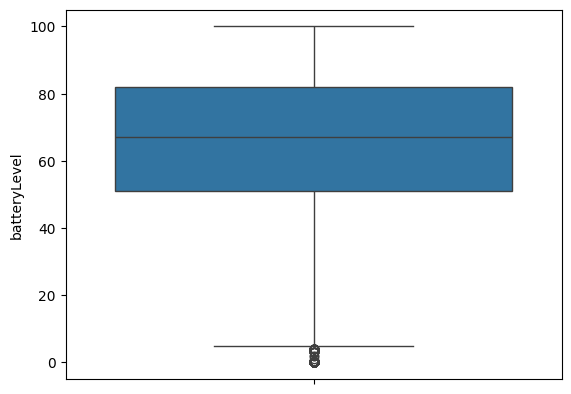

In [123]:
sns.boxplot(df['batteryLevel'])

In [124]:
df['batteryLevel'].min()

np.int64(0)

In [125]:
df['batteryLevel'].max()

np.int64(100)

In [126]:
# ============================================================
# FIX INVALID BATTERY VALUES
# ============================================================

df.loc[df["batteryLevel"] < 0, "batteryLevel"] = 0
df.loc[df["batteryLevel"] > 100, "batteryLevel"] = 100

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425960 entries, 0 to 425959
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   trolleyId     425960 non-null  int64         
 1   timestamp     425960 non-null  datetime64[us]
 2   batteryLevel  425960 non-null  int64         
 3   batteryFault  425960 non-null  str           
 4   status        425960 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 26.0 MB


In [128]:
# ============================================================
# REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates(
    subset=[
        "trolleyId",
        "timestamp",
        "batteryLevel"
    ]
)


In [129]:
df.info()

<class 'pandas.DataFrame'>
Index: 425182 entries, 0 to 425959
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   trolleyId     425182 non-null  int64         
 1   timestamp     425182 non-null  datetime64[us]
 2   batteryLevel  425182 non-null  int64         
 3   batteryFault  425182 non-null  str           
 4   status        425182 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 29.2 MB


In [130]:
# ============================================================
# SORT BY TROLLEY + TIME
# ============================================================

df = df.sort_values(
    by=[
        "trolleyId",
        "timestamp"
    ]
).reset_index(drop=True)

In [132]:
df.head(20)

,trolleyId,timestamp,batteryLevel,batteryFault,status
0,0,2025-12-22 06:42:08,93,2A:0000 2B:0000 2F:0001,1
1,0,2025-12-22 06:42:18,93,2A:0000 2B:0000 2F:0001,1
2,0,2025-12-22 07:13:14,96,2A:0000 2B:0000 2F:0001,1
3,0,2025-12-22 07:13:24,96,2A:0000 2B:0000 2F:0001,1
4,0,2025-12-22 07:18:11,98,2A:0000 2B:0000 2F:0001,1
5,0,2025-12-22 07:18:21,98,2A:0000 2B:0000 2F:0001,1
6,0,2025-12-22 07:18:44,81,2A:0000 2B:0000 2F:0001,1
7,0,2025-12-22 07:18:46,87,2A:0000 2B:0000 2F:0001,1
8,0,2025-12-22 07:18:49,85,2A:0000 2B:0000 2F:0001,1
9,0,2025-12-22 07:18:54,80,2A:0000 2B:0000 2F:0001,1


In [133]:
df1=df.copy()

In [136]:
df1.head()

,trolleyId,timestamp,batteryLevel,batteryFault,status
0,0,2025-12-22 06:42:08,93,2A:0000 2B:0000 2F:0001,1
1,0,2025-12-22 06:42:18,93,2A:0000 2B:0000 2F:0001,1
2,0,2025-12-22 07:13:14,96,2A:0000 2B:0000 2F:0001,1
3,0,2025-12-22 07:13:24,96,2A:0000 2B:0000 2F:0001,1
4,0,2025-12-22 07:18:11,98,2A:0000 2B:0000 2F:0001,1


In [137]:
df = df1.sort_values(
    by=[
        "trolleyId",
        "batteryLevel",
        "timestamp"
    ],
    ascending=[
        True,   # trolleyId ASC
        False,  # batteryLevel DESC
        True    # timestamp ASC
    ]
).reset_index(drop=True)

,trolleyId,timestamp,batteryLevel,batteryFault,status
0,0,2025-12-22 06:42:08,93,2A:0000 2B:0000 2F:0001,1
1,0,2025-12-22 06:42:18,93,2A:0000 2B:0000 2F:0001,1
2,0,2025-12-22 07:13:14,96,2A:0000 2B:0000 2F:0001,1
3,0,2025-12-22 07:13:24,96,2A:0000 2B:0000 2F:0001,1
4,0,2025-12-22 07:18:11,98,2A:0000 2B:0000 2F:0001,1
5,0,2025-12-22 07:18:21,98,2A:0000 2B:0000 2F:0001,1
6,0,2025-12-22 07:18:44,81,2A:0000 2B:0000 2F:0001,1
7,0,2025-12-22 07:18:46,87,2A:0000 2B:0000 2F:0001,1
8,0,2025-12-22 07:18:49,85,2A:0000 2B:0000 2F:0001,1
9,0,2025-12-22 07:18:54,80,2A:0000 2B:0000 2F:0001,1


In [138]:
# Step 1: Sort by trolleyId + timestamp only
df = df1.sort_values(
    by=["trolleyId", "timestamp"],
    ascending=[True, True]
).reset_index(drop=True)

# Step 2: Detect actual charging events (big jump = new charge session)
# Threshold: if battery increases by more than 5 units, treat as new charge session
CHARGE_THRESHOLD = 5

df["battery_diff"] = df.groupby("trolleyId")["batteryLevel"].diff()
df["is_new_session"] = df["battery_diff"] > CHARGE_THRESHOLD

# Step 3: Assign session IDs per trolleyId
df["session_id"] = df.groupby("trolleyId")["is_new_session"].cumsum()

# Step 4: Apply cummin within each session to remove sensor noise (small upward spikes)
df["batteryLevel_actual"] = (
    df.groupby(["trolleyId", "session_id"])["batteryLevel"]
    .cummin()
)

# Step 5: Get max and min per trolleyId per session
session_summary = (
    df.groupby(["trolleyId", "session_id"])
    .agg(
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        battery_max=("batteryLevel_actual", "max"),  # start of discharge
        battery_min=("batteryLevel_actual", "min"),  # end of discharge
    )
    .reset_index()
)



In [141]:
session_summary.head(200)

,trolleyId,session_id,session_start,session_end,battery_max,battery_min
0,0,0,2025-12-22 06:42:08,2025-12-22 07:18:44,93,81
1,0,1,2025-12-22 07:18:46,2025-12-22 07:18:54,87,80
2,0,2,2025-12-22 07:18:56,2025-12-22 07:19:44,87,79
3,0,3,2025-12-22 07:19:53,2025-12-22 07:20:02,93,80
4,0,4,2025-12-22 07:20:03,2025-12-22 07:20:12,93,80
...,...,...,...,...,...,...
195,0,195,2026-01-08 22:32:36,2026-01-08 22:32:42,83,65
196,0,196,2026-01-08 22:32:43,2026-01-08 22:32:49,83,64
197,0,197,2026-01-08 22:37:35,2026-01-08 22:37:42,83,64
198,0,198,2026-01-08 22:37:44,2026-01-08 22:42:44,83,64


In [142]:
# ============================================================
# BATTERY HEALTH KPI ANALYSIS
# ============================================================

# FLOW:
#
# RAW DEVICE DATA
# ↓
# REMOVE DUPLICATES
# ↓
# SORT BY TROLLEY + TIME
# ↓
# CALCULATE BATTERY DIFFERENCE
# ↓
# HANDLE BATTERY GLITCHES
# ↓
# DETECT CHARGING EVENTS
# ↓
# CREATE DRAIN SESSIONS
# ↓
# CALCULATE SESSION DRAIN %
# ↓
# AVERAGE DRAIN %
# ↓
# HEALTH CLASSIFICATION
# ↓
# INSIGHT GENERATION
#
# ============================================================


In [228]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd

from dotenv import load_dotenv
from sqlalchemy import create_engine

# ============================================================
# LOAD ENV VARIABLES
# ============================================================

load_dotenv()

HOST = os.getenv("DB_HOST")
USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")

DATABASE = "automated_kpi_insights"

# ============================================================
# SQLALCHEMY CONNECTION
# ============================================================

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:3306/{DATABASE}"
)

print("Connected Successfully!")

Connected Successfully!


In [229]:
# ============================================================
# LOAD DEVICE DATA
# ============================================================

query = """
SELECT
    trolleyId,
    timestamp,
    batteryLevel,
    batteryFault,
    status
FROM tbl_device_data
"""

df = pd.read_sql(query, engine)

In [230]:
# ============================================================
# KEEP ONLY ACTIVE STATUS
# ============================================================

df = df[df["status"] == 1]

In [231]:
# ============================================================
# CONVERT TIMESTAMP
# ============================================================

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

In [232]:
# ============================================================
# CONVERT BATTERY LEVEL
# ============================================================

df["batteryLevel"] = pd.to_numeric(
    df["batteryLevel"],
    errors="coerce"
)


In [233]:
# ============================================================
# REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates(
    subset=[
        "trolleyId",
        "timestamp",
        "batteryLevel"
    ]
)


In [234]:
# ============================================================
# SORT BY TROLLEY + TIME
# ============================================================

df = df.sort_values(
    by=[
        "trolleyId",
        "timestamp"
    ]
).reset_index(drop=True)

In [235]:
df.tail()

,trolleyId,timestamp,batteryLevel,batteryFault,status
425177,501,2026-05-11 03:04:33,52,2A:0000 2B:0000 2F:0001,1
425178,501,2026-05-11 03:31:20,52,2A:0000 2B:0000 2F:0001,1
425179,501,2026-05-11 03:46:32,52,2A:0000 2B:0000 2F:0001,1
425180,501,2026-05-11 04:17:19,53,2A:0000 2B:0000 2F:0001,1
425181,501,2026-05-11 04:32:24,52,2A:0000 2B:0000 2F:0001,1


In [236]:
# ============================================================
# GET PREVIOUS BATTERY LEVEL
# ============================================================

df["prev_battery"] = (
    df.groupby("trolleyId")["batteryLevel"]
    .shift(1)
)

# ============================================================
# CALCULATE BATTERY DIFFERENCE
# ============================================================

df["battery_diff"] = (
    df["batteryLevel"]
    -
    df["prev_battery"]
)

In [237]:
df.head()

,trolleyId,timestamp,batteryLevel,batteryFault,status,prev_battery,battery_diff
0,0,2025-12-22 06:42:08,93,2A:0000 2B:0000 2F:0001,1,NaN,NaN
1,0,2025-12-22 06:42:18,93,2A:0000 2B:0000 2F:0001,1,93.0,0.0
2,0,2025-12-22 07:13:14,96,2A:0000 2B:0000 2F:0001,1,93.0,3.0
3,0,2025-12-22 07:13:24,96,2A:0000 2B:0000 2F:0001,1,96.0,0.0
4,0,2025-12-22 07:18:11,98,2A:0000 2B:0000 2F:0001,1,96.0,2.0


In [238]:
# STEP 1 — CREATE SESSION FLAG
df["new_session"] = np.where(
    df["battery_diff"] > 20,
    1,
    0
)

In [239]:
df.head()

,trolleyId,timestamp,batteryLevel,batteryFault,status,prev_battery,battery_diff,new_session
0,0,2025-12-22 06:42:08,93,2A:0000 2B:0000 2F:0001,1,NaN,NaN,0
1,0,2025-12-22 06:42:18,93,2A:0000 2B:0000 2F:0001,1,93.0,0.0,0
2,0,2025-12-22 07:13:14,96,2A:0000 2B:0000 2F:0001,1,93.0,3.0,0
3,0,2025-12-22 07:13:24,96,2A:0000 2B:0000 2F:0001,1,96.0,0.0,0
4,0,2025-12-22 07:18:11,98,2A:0000 2B:0000 2F:0001,1,96.0,2.0,0


In [240]:
df['new_session'].value_counts()

new_session
0    410668
1     14514
Name: count, dtype: int64

In [241]:
#STEP 2 — CREATE SESSION IDs

df["session_id"] = (
    df.groupby("trolleyId")["new_session"]
    .cumsum()
    + 1
)

In [244]:
df['session_id'].value_counts()

session_id
1        228861
2         71204
3         21455
4          5767
5           554
          ...  
14192         1
14224         1
14262         1
14272         1
14323         1
Name: count, Length: 14323, dtype: int64

In [227]:
df

3

In [245]:
# ============================================================
# SESSION START BATTERY
# ============================================================

session_start = (
    df.groupby(
        ["trolleyId", "session_id"]
    )["batteryLevel"]
    .first()
    .reset_index(name="start_battery")
)

print(session_start.head(20))

    trolleyId  session_id  start_battery
0           0           1             93
1           0           2             88
2           0           3             49
3           0           4             49
4           0           5             50
5           0           6             49
6           0           7             49
7           0           8             49
8           0           9             49
9           0          10             49
10          0          11             49
11          0          12             49
12          0          13             49
13          0          14             49
14          0          15             49
15          0          16             50
16          0          17             49
17          0          18             49
18          0          19             49
19          0          20             49


In [246]:
# ============================================================
# SESSION END BATTERY
# ============================================================

session_end = (
    df.groupby(
        ["trolleyId", "session_id"]
    )["batteryLevel"]
    .last()
    .reset_index(name="end_battery")
)

print(session_end.head(20))

    trolleyId  session_id  end_battery
0           0           1            2
1           0           2            0
2           0           3            0
3           0           4            0
4           0           5            0
5           0           6            0
6           0           7            0
7           0           8            0
8           0           9            0
9           0          10            0
10          0          11            0
11          0          12            0
12          0          13            0
13          0          14            0
14          0          15            0
15          0          16           28
16          0          17            0
17          0          18           28
18          0          19            0
19          0          20           27


In [247]:
# ============================================================
# MERGE START + END
# ============================================================

session_df = pd.merge(
    session_start,
    session_end,
    on=[
        "trolleyId",
        "session_id"
    ]
)

print(session_df.head(20))

    trolleyId  session_id  start_battery  end_battery
0           0           1             93            2
1           0           2             88            0
2           0           3             49            0
3           0           4             49            0
4           0           5             50            0
5           0           6             49            0
6           0           7             49            0
7           0           8             49            0
8           0           9             49            0
9           0          10             49            0
10          0          11             49            0
11          0          12             49            0
12          0          13             49            0
13          0          14             49            0
14          0          15             49            0
15          0          16             50           28
16          0          17             49            0
17          0          18   

In [248]:
# ============================================================
# CALCULATE DRAIN PERCENTAGE
# ============================================================

session_df["drain_percentage"] = (
    session_df["start_battery"]
    -
    session_df["end_battery"]
)

print(session_df.head(20))

    trolleyId  session_id  start_battery  end_battery  drain_percentage
0           0           1             93            2                91
1           0           2             88            0                88
2           0           3             49            0                49
3           0           4             49            0                49
4           0           5             50            0                50
5           0           6             49            0                49
6           0           7             49            0                49
7           0           8             49            0                49
8           0           9             49            0                49
9           0          10             49            0                49
10          0          11             49            0                49
11          0          12             49            0                49
12          0          13             49            0           